# Explore nitrate violations

Working with Luka to explore the data he downloaded.


In [11]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
dir_data = '/Users/jgomezvelez/Downloads/nitrate_violations'
filename = 'dataset_violations.pkl'

dataset = pd.read_pickle(os.path.join(dir_data, filename))

dataset.loc[dataset['Contaminant'] == 'Nirate-Nitrite', 'Contaminant'] = 'Nitrate-Nitrite'

dataset.head()



,Submission Year Quarter,EPA Region,Primacy Agency Code,Primacy Type,PWS ID,PWS Name,PWS Type,GW SW,Primary Source,PWS Activity Type,...,Rule Name,Violation Type,Compliance Period Begin Date,Compliance Period End Date,Compliance Status,RTC Date,Year,Quarter,Violation,Contaminant
0,2013Q1,7,IA,State,IA0709207,ORDER OF EAGLES/AERIE 4074,Transient non-community system,Surface water,Groundwater under influence of surface water,Inactive,...,Nitrate Rule,"Maximum Contaminant Level Violation, Single Sa...",1985-06-08,1985-07-07,System Inactive,1997-08-05,2013,1,1,Nitrate
1,2013Q1,7,IA,State,IA0709207,ORDER OF EAGLES/AERIE 4074,Transient non-community system,Surface water,Groundwater under influence of surface water,Inactive,...,Nitrate Rule,"Maximum Contaminant Level Violation, Single Sa...",1984-11-01,1985-09-30,System Inactive,1997-08-05,2013,1,1,Nitrate
2,2013Q1,7,IA,State,IA0709207,ORDER OF EAGLES/AERIE 4074,Transient non-community system,Surface water,Groundwater under influence of surface water,Inactive,...,Nitrate Rule,"Maximum Contaminant Level Violation, Single Sa...",1997-01-01,1997-01-31,System Inactive,1997-08-05,2013,1,1,Nitrate
3,2013Q1,7,IA,State,IA0709207,ORDER OF EAGLES/AERIE 4074,Transient non-community system,Surface water,Groundwater under influence of surface water,Inactive,...,Nitrate Rule,"Maximum Contaminant Level Violation, Single Sa...",1997-04-01,1997-04-30,System Inactive,1997-08-05,2013,1,1,Nitrate
4,2013Q1,7,IA,State,IA0709207,ORDER OF EAGLES/AERIE 4074,Transient non-community system,Surface water,Groundwater under influence of surface water,Inactive,...,Nitrate Rule,"Maximum Contaminant Level Violation, Single Sa...",1992-03-01,1992-03-31,Returned to Compliance,1996-06-06,2013,1,1,Nitrate


In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 389972 entries, 0 to 240
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   Submission Year Quarter       389972 non-null  object        
 1   EPA Region                    389972 non-null  int64         
 2   Primacy Agency Code           389972 non-null  object        
 3   Primacy Type                  389972 non-null  object        
 4   PWS ID                        389972 non-null  object        
 5   PWS Name                      389972 non-null  object        
 6   PWS Type                      389972 non-null  object        
 7   GW SW                         389972 non-null  object        
 8   Primary Source                389972 non-null  object        
 9   PWS Activity Type             389972 non-null  object        
 10  PWS Deactivation Date         162483 non-null  datetime64[ns]
 11  Population Served Cou

In [18]:
dataset.shape

(389972, 25)

In [ ]:
print('Years: ', dataset['Year'].unique())
print('Quarters: ', dataset['Quarter'].unique())
print('Violations: ', dataset['Violation'].unique())
print('Contaminants: ', dataset['Contaminant'].unique())


Years:  [2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]
Quarters:  [1 2 3 4]
Violations:  [1 2 3 4]
Contaminants:  ['Nitrate' 'Nitrate-Nitrite']


In [58]:
dataset['GW SW'].unique()

array(['Surface water', 'Groundwater'], dtype=object)

In [7]:
dataset.loc[dataset['Contaminant'] == 'Nirate-Nitrite', ['Year', 'Quarter', 'Violation', 'Contaminant']]

,Year,Quarter,Violation,Contaminant
0,2013,1,3,Nirate-Nitrite
1,2013,1,3,Nirate-Nitrite
2,2013,1,3,Nirate-Nitrite
3,2013,1,3,Nirate-Nitrite
4,2013,1,3,Nirate-Nitrite
...,...,...,...,...
0,2025,4,3,Nirate-Nitrite
1,2025,4,3,Nirate-Nitrite
2,2025,4,3,Nirate-Nitrite
3,2025,4,3,Nirate-Nitrite


In [54]:
subset = dataset.loc[(dataset['Contaminant'] == 'Nitrate') & (dataset['Violation'] == 2) & (dataset['PWS Type'] == 'Community water system')].copy(deep=True)
subset.shape

(7393, 25)

In [55]:
subset.loc[subset['Year'] == 2025].shape

(560, 25)

In [59]:
subset_agg = subset.groupby(['Year', 'GW SW']).size().reset_index(name='Result')
subset_agg

,Year,GW SW,Result
0,2013,Groundwater,500
1,2013,Surface water,68
2,2014,Groundwater,500
3,2014,Surface water,68
4,2015,Groundwater,500
5,2015,Surface water,68
6,2016,Groundwater,503
7,2016,Surface water,68
8,2017,Groundwater,506
9,2017,Surface water,66


In [47]:
subset.loc[subset['Year'] == 2025].head(10)

,Submission Year Quarter,EPA Region,Primacy Agency Code,Primacy Type,PWS ID,PWS Name,PWS Type,GW SW,Primary Source,PWS Activity Type,...,Rule Name,Violation Type,Compliance Period Begin Date,Compliance Period End Date,Compliance Status,RTC Date,Year,Quarter,Violation,Contaminant
0,2025Q1,7,IA,State,IA0709207,ORDER OF EAGLES/AERIE 4074,Transient non-community system,Surface water,Groundwater under influence of surface water,Inactive,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1985-10-01,1986-09-30,System Inactive,1997-08-05,2025,1,2,Nitrate
1,2025Q1,7,IA,State,IA0709207,ORDER OF EAGLES/AERIE 4074,Transient non-community system,Surface water,Groundwater under influence of surface water,Inactive,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1984-10-01,1984-10-31,Returned to Compliance,1996-06-06,2025,1,2,Nitrate
2,2025Q1,7,IA,State,IA8439058,HOSPERS MUNICIPAL WATER DEPT,Community water system,Surface water,Purchased ground water under influence of surf...,Active,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1979-07-24,1980-10-23,Known,NaT,2025,1,2,Nitrate
3,2025Q1,7,IA,State,IA1570032,WIOTA WATER WORKS,Community water system,Groundwater,Ground water,Active,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1976-10-01,1979-09-30,Known,NaT,2025,1,2,Nitrate
4,2025Q1,7,IA,State,IA7239086,OCHEYEDAN WATER WORKS,Community water system,Groundwater,Ground water,Active,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1993-08-01,1993-08-31,Known,NaT,2025,1,2,Nitrate
5,2025Q1,7,IA,State,IA6668001,ORCHARD WATER WORKS,Community water system,Groundwater,Ground water,Active,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1979-09-21,1980-10-20,Known,NaT,2025,1,2,Nitrate
6,2025Q1,7,IA,State,IA1880073,WASHTA WATER SUPPLY,Community water system,Groundwater,Ground water,Active,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1979-05-09,1980-10-08,Known,NaT,2025,1,2,Nitrate
7,2025Q1,7,IA,State,IA1535078,LEWIS WATER SUPPLY,Community water system,Groundwater,Ground water,Active,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1981-10-01,1982-09-30,Known,NaT,2025,1,2,Nitrate
8,2025Q1,7,IA,State,IA1535078,LEWIS WATER SUPPLY,Community water system,Groundwater,Ground water,Active,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1978-12-20,1980-10-19,Known,NaT,2025,1,2,Nitrate
9,2025Q1,7,IA,State,IA9725094,CUSHING WATER SUPPLY,Community water system,Groundwater,Ground water,Active,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1978-06-26,1979-06-25,Known,NaT,2025,1,2,Nitrate


In [46]:
subset.loc[subset['Year'] == 2024].head(10)

,Submission Year Quarter,EPA Region,Primacy Agency Code,Primacy Type,PWS ID,PWS Name,PWS Type,GW SW,Primary Source,PWS Activity Type,...,Rule Name,Violation Type,Compliance Period Begin Date,Compliance Period End Date,Compliance Status,RTC Date,Year,Quarter,Violation,Contaminant
0,2024Q1,7,IA,State,IA0709207,ORDER OF EAGLES/AERIE 4074,Transient non-community system,Surface water,Groundwater under influence of surface water,Inactive,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1985-10-01,1986-09-30,System Inactive,1997-08-05,2024,1,2,Nitrate
1,2024Q1,7,IA,State,IA0709207,ORDER OF EAGLES/AERIE 4074,Transient non-community system,Surface water,Groundwater under influence of surface water,Inactive,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1984-10-01,1984-10-31,Returned to Compliance,1996-06-06,2024,1,2,Nitrate
2,2024Q1,7,IA,State,IA8439058,HOSPERS MUNICIPAL WATER DEPT,Community water system,Surface water,Purchased ground water under influence of surf...,Active,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1979-07-24,1980-10-23,Known,NaT,2024,1,2,Nitrate
3,2024Q1,7,IA,State,IA7239086,OCHEYEDAN WATER WORKS,Community water system,Groundwater,Ground water,Active,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1993-08-01,1993-08-31,Known,NaT,2024,1,2,Nitrate
4,2024Q1,7,IA,State,IA1570032,WIOTA WATER WORKS,Community water system,Groundwater,Ground water,Active,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1976-10-01,1979-09-30,Known,NaT,2024,1,2,Nitrate
5,2024Q1,7,IA,State,IA9725094,CUSHING WATER SUPPLY,Community water system,Groundwater,Ground water,Active,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1978-06-26,1979-06-25,Known,NaT,2024,1,2,Nitrate
6,2024Q1,7,IA,State,IA9725094,CUSHING WATER SUPPLY,Community water system,Groundwater,Ground water,Active,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1978-09-18,1980-10-17,Known,NaT,2024,1,2,Nitrate
7,2024Q1,7,IA,State,IA1880073,WASHTA WATER SUPPLY,Community water system,Groundwater,Ground water,Active,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1981-10-01,1982-09-30,Known,NaT,2024,1,2,Nitrate
8,2024Q1,7,IA,State,IA1880073,WASHTA WATER SUPPLY,Community water system,Groundwater,Ground water,Active,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1979-05-09,1980-10-08,Known,NaT,2024,1,2,Nitrate
9,2024Q1,7,IA,State,IA1535078,LEWIS WATER SUPPLY,Community water system,Groundwater,Ground water,Active,...,Nitrate Rule,"Maximum Contaminant Level Violation, Average",1981-10-01,1982-09-30,Known,NaT,2024,1,2,Nitrate


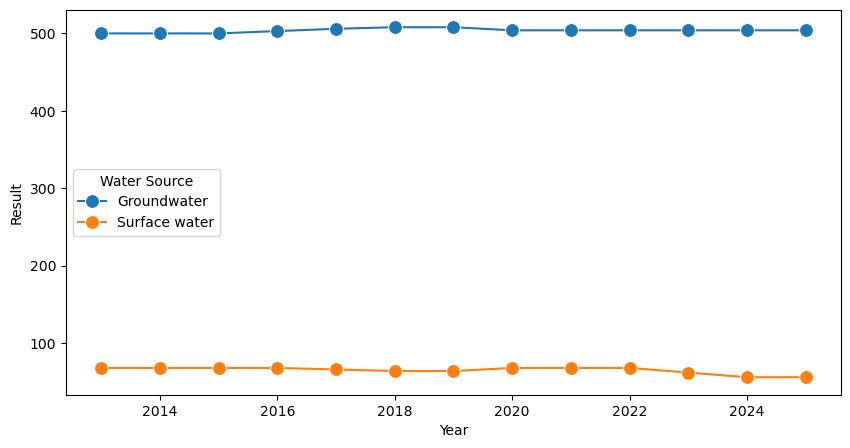

In [68]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x='Year', y='Result', hue='GW SW', data=subset_agg, ax=ax, marker='o', markersize=10)
ax.legend(title='Water Source', loc='center left')

